<a href="https://colab.research.google.com/github/ERA-Software/computational-data-analysis/blob/notebook_s5/notebooks/S5_regression_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning and Regression
**Computational Data Analysis with Python | Lecture 5**

This notebook is a self-contained 60-minute lecture on regression methods for data-based modeling. We build from first principles (what is supervised learning?) to practical tools (OLS, Bayesian regression, PLS) and emphasize visual intuition throughout.

**Outline (~60 min)**

| Block | Topic | Time |
|:---|:---|:---|
| 0 | Data analysis vs. data science; learning paradigms | ~8 min |
| 1 | OLS as the baseline | ~10 min |
| 2 | Train/validation/test & diagnostics | ~10 min |
| 3 | Bayesian linear regression | ~12 min |
| 4 | PCR, PLS, and Ridge | ~12 min |
| 5 | Feature selection & wrap-up | ~8 min |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
BLUE = '#1e5aa8'
RED  = '#e74c3c'
GOLD = '#f39c12'
GREEN = '#27ae60'
GRAY = '#7f8c8d'

np.random.seed(42)

---
## Block 0: From Data Analysis to Prediction

### Data analysis vs. data science

| | Data Analysis | Data Science / ML |
|:---|:---|:---|
| **Goal** | Understand patterns, summarize, explain | Predict unseen outcomes |
| **Output** | Insights, visualizations, hypothesis tests | Predictive models, automated decisions |
| **Evaluation** | Does the story make sense? | Does the model generalize? |

Data analysis asks *"what happened and why?"*. Data science asks *"what will happen next?"*. This lecture bridges the two: we start from OLS (a classic data-analysis tool) and extend it toward predictive modeling.

### Three families of machine learning

Learning algorithms are distinguished by the **supervision signal** they receive.

| Paradigm | Data | Learns | Examples |
|:---|:---|:---|:---|
| **Supervised** | Labeled pairs $\{(x_i, y_i)\}$ | A mapping $f: X \to Y$ | Regression, classification |
| **Unsupervised** | Unlabeled $\{x_i\}$ | Structure (clusters, factors) | $k$-means, PCA, autoencoders |
| **Reinforcement** | States, actions, rewards | A policy $\pi(a \mid s)$ | Game-playing, robotics |

**Self-supervised learning** deserves a special mention: the labels are derived from the data itself (e.g., predicting a masked word from its context in BERT, or predicting one image crop from another in DINOv2). There are no human annotations, yet the learning objective is a supervised loss. It sits between supervised and unsupervised learning and powers most modern foundation models.

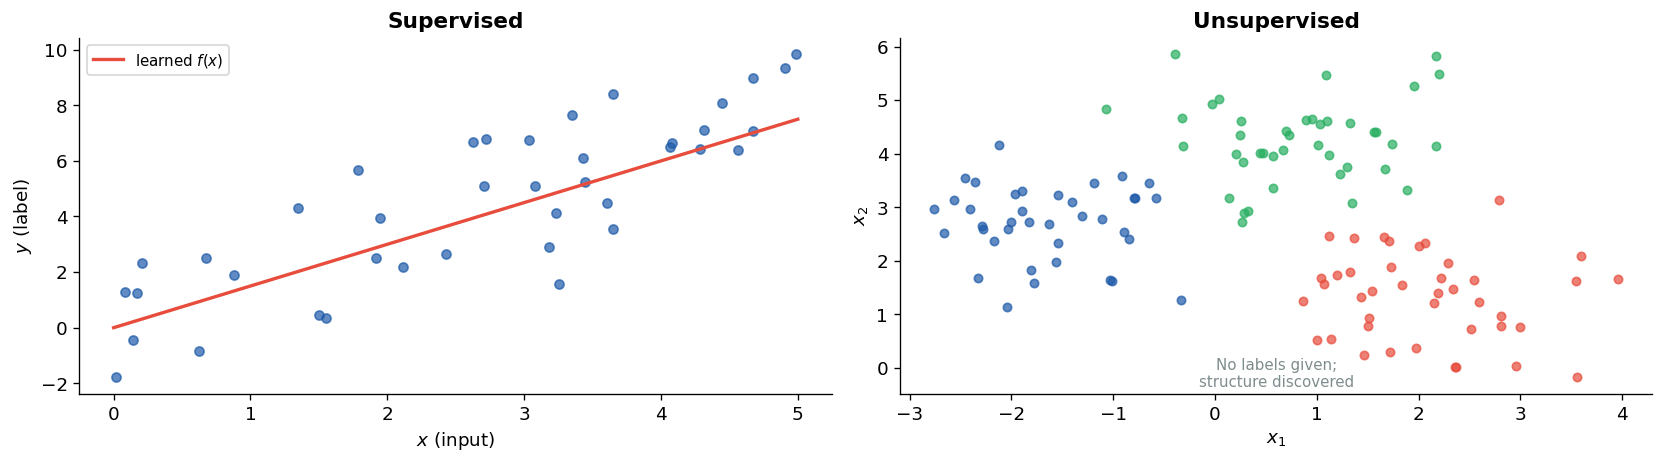

In [3]:
# Visual: the three learning paradigms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Supervised: labeled scatter ---
rng = np.random.default_rng(0)
x_s = rng.uniform(0, 5, 40)
y_s = 1.5 * x_s + rng.normal(0, 1.5, 40)
axes[0].scatter(x_s, y_s, c=BLUE, s=30, alpha=0.7)
xfit = np.array([0, 5])
axes[0].plot(xfit, 1.5 * xfit, color=RED, lw=2, label='learned $f(x)$')
axes[0].set_xlabel('$x$ (input)')
axes[0].set_ylabel('$y$ (label)')
axes[0].set_title('Supervised', fontweight='bold')
axes[0].legend(fontsize=9)

# --- Unsupervised: clusters ---
from sklearn.datasets import make_blobs
X_blob, _ = make_blobs(n_samples=120, centers=3, cluster_std=0.8, random_state=0)
colors_blob = ['#1e5aa8', '#e74c3c', '#27ae60']
from sklearn.cluster import KMeans
km = KMeans(3, random_state=0, n_init=10).fit(X_blob)
for k in range(3):
    mask = km.labels_ == k
    axes[1].scatter(X_blob[mask, 0], X_blob[mask, 1], c=colors_blob[k], s=25, alpha=0.7)
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_title('Unsupervised', fontweight='bold')
axes[1].annotate('No labels given;\nstructure discovered', xy=(0.5, 0.02),
                 xycoords='axes fraction', ha='center', fontsize=9, color=GRAY)

plt.tight_layout()
plt.show()

### Within supervised learning: regression vs. classification

Both tasks share the same workflow (choose model, define loss, fit, evaluate). The difference is in the **nature of the target**:

| | Regression | Classification |
|:---|:---|:---|
| **Target** | Continuous $y \in \mathbb{R}$ | Discrete $y \in \{1, \ldots, C\}$ |
| **Loss** | Squared error, absolute error | Cross-entropy, 0-1 loss |
| **Example** | Predict hourly bike rentals | Predict penguin species |

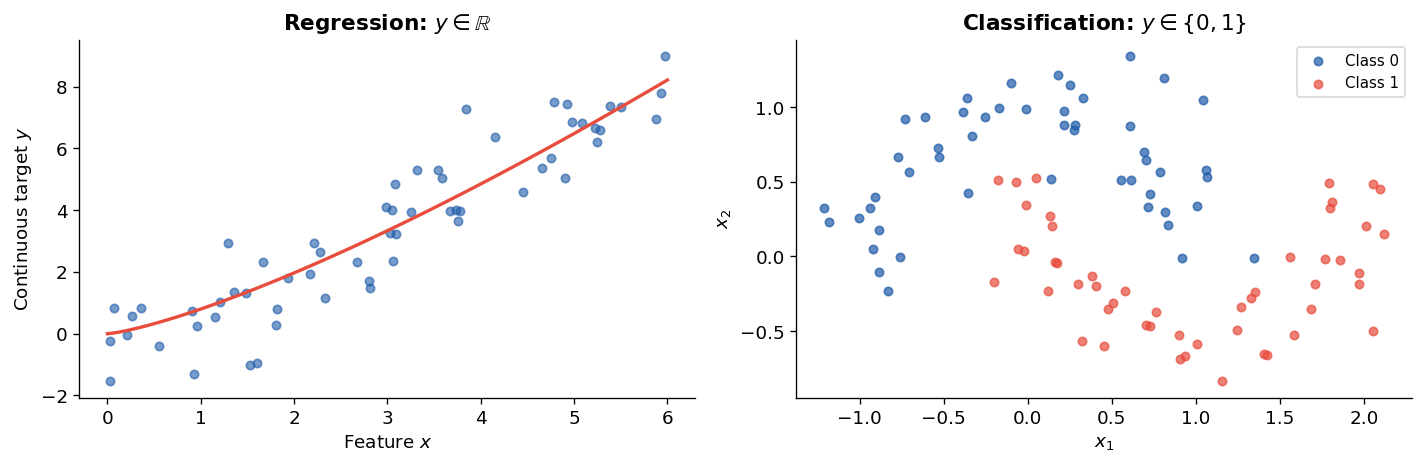

In [3]:
# Visual: regression vs classification side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regression
rng = np.random.default_rng(7)
x_r = rng.uniform(0, 6, 60)
y_r = 0.8 * x_r**1.3 + rng.normal(0, 1.2, 60)
axes[0].scatter(x_r, y_r, c=BLUE, s=25, alpha=0.6)
x_line = np.linspace(0, 6, 100)
axes[0].plot(x_line, 0.8 * x_line**1.3, color=RED, lw=2)
axes[0].set_xlabel('Feature $x$')
axes[0].set_ylabel('Continuous target $y$')
axes[0].set_title('Regression: $y \\in \\mathbb{R}$', fontweight='bold')

# Classification
from sklearn.datasets import make_moons
X_moon, y_moon = make_moons(n_samples=100, noise=0.2, random_state=0)
axes[1].scatter(X_moon[y_moon==0, 0], X_moon[y_moon==0, 1],
               c=BLUE, s=25, alpha=0.7, label='Class 0')
axes[1].scatter(X_moon[y_moon==1, 0], X_moon[y_moon==1, 1],
               c=RED, s=25, alpha=0.7, label='Class 1')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_title('Classification: $y \\in \\{0, 1\\}$', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**This lecture focuses on regression.** Classification follows in the next lecture.

---
## Block 1: OLS as the Baseline

### The dataset

We use a single synthetic dataset throughout the entire notebook so that every concept builds on the same visual intuition. The data-generating process is:

$$y = 3 + 2x_1 - 1.5 x_2 + 0.5 x_1 x_2 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 2^2)$$

This gives us a known ground truth to compare against.

In [4]:
# --- Continuing dataset used throughout the notebook ---
np.random.seed(42)
n = 200
x1 = np.random.uniform(0, 5, n)
x2 = np.random.uniform(0, 5, n)
noise = np.random.normal(0, 2, n)
y_true_fn = lambda x1, x2: 3 + 2*x1 - 1.5*x2 + 0.5*x1*x2
y = y_true_fn(x1, x2) + noise

# We will initially model this with x1 alone (to visualize 2D), then expand.
X_1d = x1.reshape(-1, 1)
X_2d = np.column_stack([x1, x2])

print(f"Dataset: n = {n} observations")
print(f"True model: y = 3 + 2*x1 - 1.5*x2 + 0.5*x1*x2 + noise")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")

Dataset: n = 200 observations
True model: y = 3 + 2*x1 - 1.5*x2 + 0.5*x1*x2 + noise
y range: [-4.3, 17.4]


### The OLS model

Ordinary Least Squares assumes a linear relationship with additive Gaussian noise:

$$y = X\beta + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)$$

This encodes four assumptions:
1. **Linearity:** $\mathbb{E}[y \mid X] = X\beta$ (linear in parameters).
2. **Independence:** errors $\varepsilon_i$ are independent across observations.
3. **Homoscedasticity:** $\text{Var}(\varepsilon_i) = \sigma^2$ is constant.
4. **Normality:** $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ (needed for exact inference; not strictly required for estimation).

The OLS solution minimizes the sum of squared residuals:

$$\hat{\beta}_{\text{OLS}} = \arg\min_\beta \|y - X\beta\|_2^2 = (X^\top X)^{-1} X^\top y$$

**Geometric interpretation:** OLS projects $y$ onto the column space of $X$. The residual vector $e = y - X\hat{\beta}$ is orthogonal to every column of $X$.

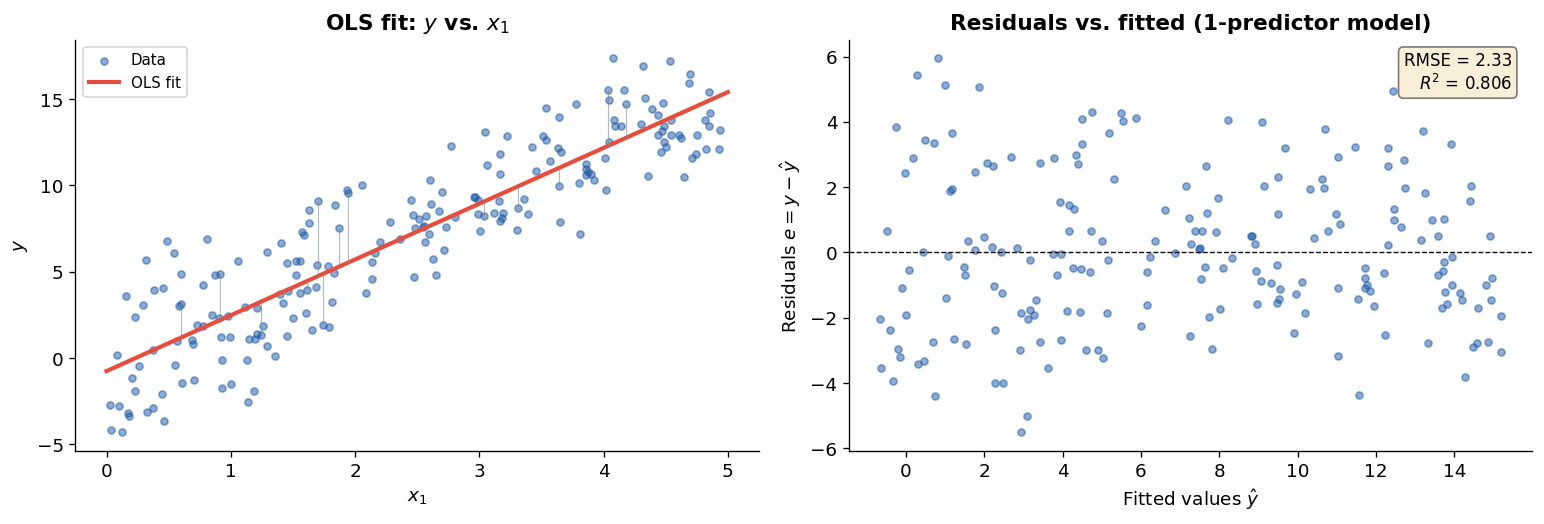


OLS with x1 only: intercept = -0.749, slope = 3.231
(True DGP has interaction term, so the 1D model is misspecified.)


In [5]:
# Fit OLS with x1 only
ols_1d = LinearRegression().fit(X_1d, y)
y_pred_1d = ols_1d.predict(X_1d)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: data + fitted line
x_grid = np.linspace(0, 5, 100).reshape(-1, 1)
axes[0].scatter(x1, y, c=BLUE, s=18, alpha=0.5, label='Data')
axes[0].plot(x_grid, ols_1d.predict(x_grid), color=RED, lw=2.5, label='OLS fit')
# Show a few residual lines
for i in range(0, n, 15):
    axes[0].plot([x1[i], x1[i]], [y[i], y_pred_1d[i]], color=GRAY, lw=0.7, alpha=0.6)
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$y$')
axes[0].set_title('OLS fit: $y$ vs. $x_1$', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: residuals vs. fitted
residuals_1d = y - y_pred_1d
axes[1].scatter(y_pred_1d, residuals_1d, c=BLUE, s=18, alpha=0.5)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('Fitted values $\\hat{y}$')
axes[1].set_ylabel('Residuals $e = y - \\hat{y}$')
axes[1].set_title('Residuals vs. fitted (1-predictor model)', fontweight='bold')

rmse_1d = np.sqrt(mean_squared_error(y, y_pred_1d))
r2_1d = r2_score(y, y_pred_1d)
axes[1].annotate(f'RMSE = {rmse_1d:.2f}\n$R^2$ = {r2_1d:.3f}',
                xy=(0.97, 0.97), xycoords='axes fraction', ha='right', va='top',
                fontsize=10, bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nOLS with x1 only: intercept = {ols_1d.intercept_:.3f}, slope = {ols_1d.coef_[0]:.3f}")
print(f"(True DGP has interaction term, so the 1D model is misspecified.)")

In [6]:
# Fit OLS with both x1 and x2
ols_2d = LinearRegression().fit(X_2d, y)
y_pred_2d = ols_2d.predict(X_2d)

rmse_2d = np.sqrt(mean_squared_error(y, y_pred_2d))
r2_2d = r2_score(y, y_pred_2d)
n_, p_ = X_2d.shape
adj_r2_2d = 1 - (1 - r2_2d) * (n_ - 1) / (n_ - p_ - 1)

print("OLS with x1, x2:")
print(f"  Coefficients: intercept = {ols_2d.intercept_:.3f}, "
      f"beta_1 = {ols_2d.coef_[0]:.3f}, beta_2 = {ols_2d.coef_[1]:.3f}")
print(f"  RMSE = {rmse_2d:.3f}, R^2 = {r2_2d:.3f}, Adj. R^2 = {adj_r2_2d:.3f}")
print(f"\nNote: the true model includes an interaction x1*x2 that we have not modeled.")
print(f"This means the linear model is still misspecified. The diagnostics will reveal this.")

OLS with x1, x2:
  Coefficients: intercept = 0.410, beta_1 = 3.220, beta_2 = -0.448
  RMSE = 2.237, R^2 = 0.821, Adj. R^2 = 0.820

Note: the true model includes an interaction x1*x2 that we have not modeled.
This means the linear model is still misspecified. The diagnostics will reveal this.


### A brief note on other regression models

OLS is the starting point. When its assumptions break down, we have many options:

| Model | Key idea | When to reach for it |
|:---|:---|:---|
| **Ridge** | Add $\ell_2$ penalty $\lambda\|\beta\|_2^2$ | Correlated features, unstable coefficients |
| **Lasso** | Add $\ell_1$ penalty $\lambda\|\beta\|_1$ | Need sparse solutions / feature selection |
| **Elastic Net** | Combine $\ell_1 + \ell_2$ | Correlated groups of features |
| **Polynomial / splines** | Nonlinear basis expansion | Nonlinear patterns in residuals |
| **Decision trees / forests** | Recursive partitioning | Complex interactions, no distributional assumptions |
| **Neural networks** | Flexible function approximators | Large data, complex nonlinear patterns |
| **Bayesian regression** | Full posterior over $\beta$ | Need uncertainty quantification |

The rest of this lecture covers several of these in detail.

---
## Block 2: Train / Validation / Test & Diagnostics

### The data-splitting principle

A model that fits the training data well may fail on new data (overfitting). To guard against this, we split the data into three non-overlapping sets:

| Set | Purpose | Used for |
|:---|:---|:---|
| **Training** (~60-80%) | Fit the model parameters | Estimating $\hat{\beta}$ |
| **Validation** (~10-20%) | Tune hyperparameters, select model | Choosing $\lambda$, number of components, etc. |
| **Test** (~10-20%) | Final unbiased performance estimate | Reported in papers; touched only once |

When data is scarce, **$k$-fold cross-validation** replaces the single validation set: rotate through $k$ folds, using each as validation once.

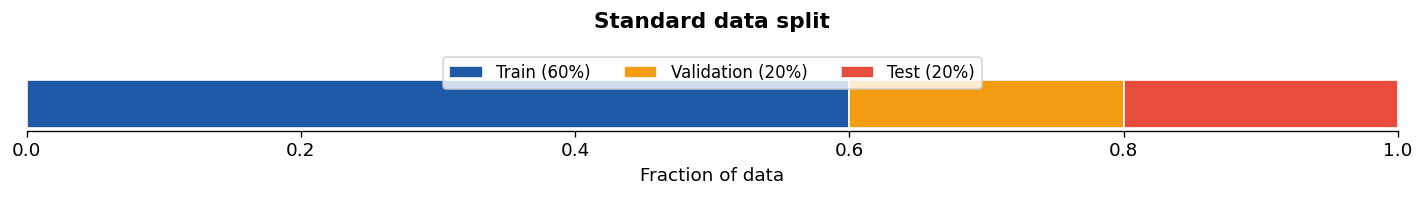

In [7]:
# Visual: train / validation / test split
fig, ax = plt.subplots(figsize=(12, 2))
ax.barh(0, 0.6, left=0, color=BLUE, edgecolor='white', height=0.5, label='Train (60%)')
ax.barh(0, 0.2, left=0.6, color=GOLD, edgecolor='white', height=0.5, label='Validation (20%)')
ax.barh(0, 0.2, left=0.8, color=RED, edgecolor='white', height=0.5, label='Test (20%)')
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Fraction of data')
ax.legend(loc='upper center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.55))
ax.set_title('Standard data split', fontweight='bold', pad=30)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

### Diagnostics for OLS

OLS always returns an answer, even when the assumptions are violated. **Diagnostics reveal whether that answer is trustworthy.**

The motto: *fit, then diagnose, then decide whether to trust.*

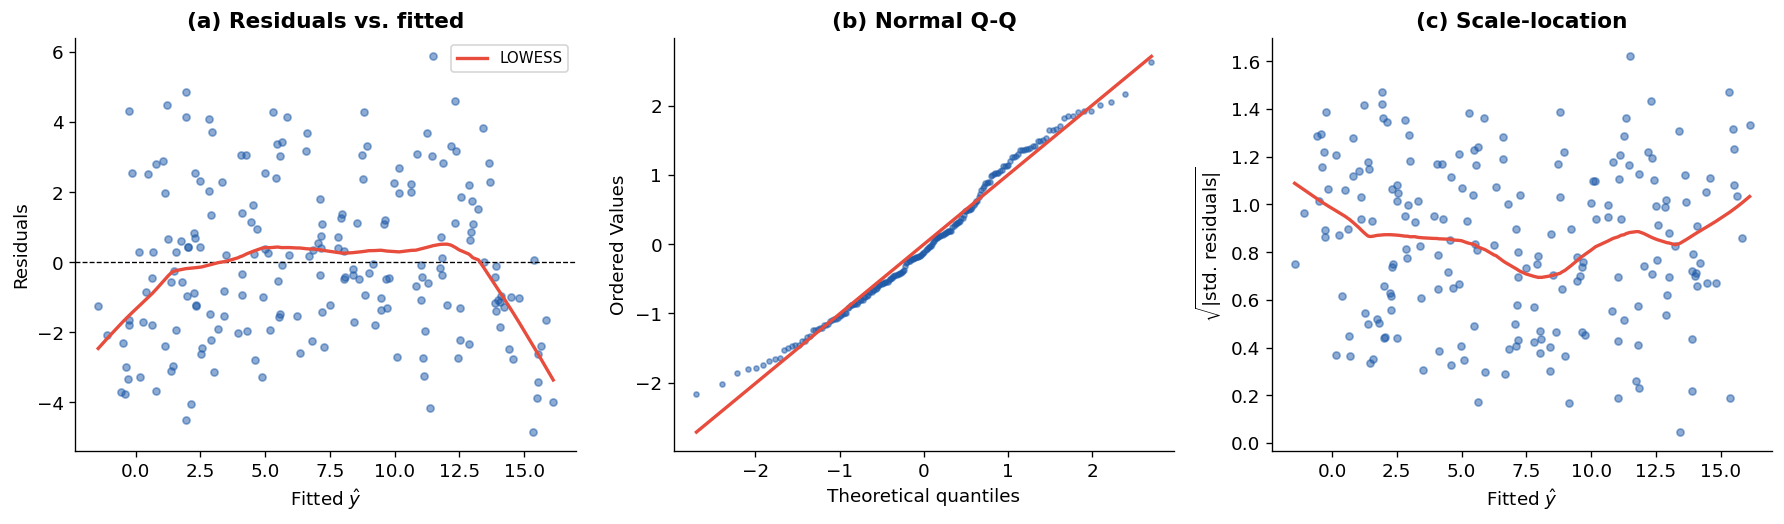

In [8]:
# Full diagnostic panel for the 2-predictor OLS model
residuals_2d = y - y_pred_2d
std_res_2d = (residuals_2d - residuals_2d.mean()) / residuals_2d.std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Residuals vs. fitted
axes[0].scatter(y_pred_2d, residuals_2d, c=BLUE, s=18, alpha=0.5)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
# LOWESS trend to reveal structure
from statsmodels.nonparametric.smoothers_lowess import lowess
lowess_fit = lowess(residuals_2d, y_pred_2d, frac=0.3)
axes[0].plot(lowess_fit[:, 0], lowess_fit[:, 1], color=RED, lw=2, label='LOWESS')
axes[0].set_xlabel('Fitted $\\hat{y}$')
axes[0].set_ylabel('Residuals')
axes[0].set_title('(a) Residuals vs. fitted', fontweight='bold')
axes[0].legend(fontsize=9)

# (b) Q-Q plot
stats.probplot(std_res_2d, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set(color=BLUE, markersize=3, alpha=0.5)
axes[1].get_lines()[1].set(color=RED, lw=2)
axes[1].set_title('(b) Normal Q-Q', fontweight='bold')

# (c) Scale-location
axes[2].scatter(y_pred_2d, np.sqrt(np.abs(std_res_2d)), c=BLUE, s=18, alpha=0.5)
sl_fit = lowess(np.sqrt(np.abs(std_res_2d)), y_pred_2d, frac=0.3)
axes[2].plot(sl_fit[:, 0], sl_fit[:, 1], color=RED, lw=2)
axes[2].set_xlabel('Fitted $\\hat{y}$')
axes[2].set_ylabel('$\\sqrt{|\\text{std. residuals}|}$')
axes[2].set_title('(c) Scale-location', fontweight='bold')

plt.tight_layout()
plt.show()

**How to read these plots:**

- **(a) Residuals vs. fitted:** Under the assumptions, this should be a random scatter around zero. A curve in the LOWESS trend indicates missed nonlinearity. A funnel shape indicates heteroscedasticity.
- **(b) Q-Q plot:** Points should lie on the diagonal. Heavy tails or S-shapes indicate non-normal residuals.
- **(c) Scale-location:** If the LOWESS line is flat, variance is roughly constant (homoscedasticity). A rising trend means variance grows with the prediction.

In our example, the LOWESS trend in (a) curves because the true data-generating process includes an interaction term $x_1 x_2$ that our linear model does not capture.

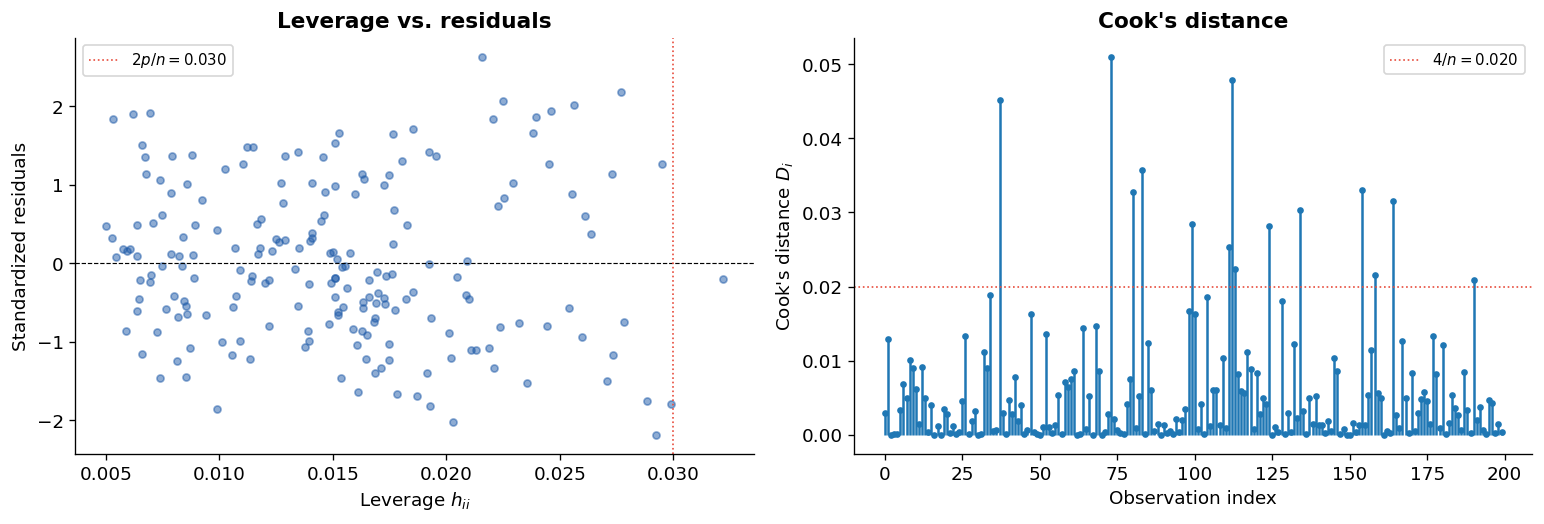

In [9]:
# Leverage and Cook's distance
X_aug = np.column_stack([np.ones(n), X_2d])
H = X_aug @ np.linalg.solve(X_aug.T @ X_aug, X_aug.T)
leverage = np.diag(H)
p_aug = X_aug.shape[1]
sigma_hat = np.sqrt(np.sum(residuals_2d**2) / (n - p_aug))
std_res_cook = residuals_2d / (sigma_hat * np.sqrt(1 - leverage))
cooks_d = (std_res_cook**2 / p_aug) * (leverage / (1 - leverage))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Leverage vs. standardized residuals
axes[0].scatter(leverage, std_res_cook, c=BLUE, s=18, alpha=0.5)
axes[0].axhline(0, color='black', lw=0.7, ls='--')
axes[0].axvline(2 * p_aug / n, color=RED, lw=1, ls=':', label=f'$2p/n = {2*p_aug/n:.3f}$')
axes[0].set_xlabel('Leverage $h_{ii}$')
axes[0].set_ylabel('Standardized residuals')
axes[0].set_title('Leverage vs. residuals', fontweight='bold')
axes[0].legend(fontsize=9)

# Cook's distance
axes[1].stem(np.arange(n), cooks_d, linefmt='-', markerfmt='.', basefmt=' ')
axes[1].axhline(4/n, color=RED, lw=1, ls=':', label=f'$4/n = {4/n:.3f}$')
axes[1].set_xlabel('Observation index')
axes[1].set_ylabel("Cook's distance $D_i$")
axes[1].set_title("Cook's distance", fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### When diagnostics say "use a more complex model"

If your residual plots show **systematic patterns** (curves, fans, clusters), the linear model is missing structure. Your options are:

1. **Add features:** interaction terms, polynomial terms, splines (stays within the linear framework, since it is still linear in parameters).
2. **Switch to a flexible model:** GAMs, random forests, gradient boosting, or neural networks.

A neural network is justified when: (i) you have a large dataset, (ii) the relationship is highly nonlinear, (iii) you care about predictive accuracy more than interpretability, and (iv) simpler models have been tried and their diagnostics show persistent misfit.

**Start simple, diagnose, then escalate.** A neural net is not a first resort.

---
## Block 3: Bayesian Linear Regression

### The idea

OLS gives a single point estimate $\hat{\beta}$. Bayesian regression treats $\beta$ as a random variable and returns a **full posterior distribution** over the coefficients. This lets us quantify uncertainty in both the coefficients and the predictions.

The three ingredients:

| Component | Formula | Role |
|:---|:---|:---|
| **Prior** | $p(\beta) = \mathcal{N}(m_0, S_0)$ | Encode beliefs before seeing data |
| **Likelihood** | $p(y \mid X, \beta, \sigma^2) = \mathcal{N}(X\beta, \sigma^2 I)$ | How well does $\beta$ explain the data? |
| **Posterior** | $p(\beta \mid y, X) \propto p(y \mid X, \beta)\, p(\beta)$ | Updated beliefs after seeing data |

For a Gaussian prior and Gaussian likelihood, the posterior is also Gaussian (conjugacy):

$$p(\beta \mid y, X) = \mathcal{N}(m_N, S_N)$$

where

$$S_N = \left(S_0^{-1} + \frac{1}{\sigma^2} X^\top X\right)^{-1}, \qquad m_N = S_N \left(S_0^{-1} m_0 + \frac{1}{\sigma^2} X^\top y\right)$$

**Connection to Ridge:** If $m_0 = 0$ and $S_0 = \tau^2 I$, the posterior mean equals the Ridge estimate with $\lambda = \sigma^2 / \tau^2$. Ridge regression is the MAP (maximum a posteriori) estimate under a zero-mean Gaussian prior.

In [10]:
# --- Bayesian linear regression: y vs x1 (1D for visualization) ---

# Design matrix with intercept
X_bay = np.column_stack([np.ones(n), x1])
p_bay = X_bay.shape[1]

# Hyperparameters
sigma2 = 4.0          # assume known noise variance (sigma = 2)
m_0 = np.zeros(p_bay)  # prior mean: no prior preference
S_0 = 10.0 * np.eye(p_bay)  # prior covariance: weakly informative (wide)

# Posterior
S_0_inv = np.linalg.inv(S_0)
S_N_inv = S_0_inv + (1.0 / sigma2) * X_bay.T @ X_bay
S_N = np.linalg.inv(S_N_inv)
m_N = S_N @ (S_0_inv @ m_0 + (1.0 / sigma2) * X_bay.T @ y)

print("Prior:")
print(f"  m_0 = {m_0}")
print(f"  S_0 = diag({S_0[0,0]})  (weakly informative)")
print(f"\nPosterior:")
print(f"  m_N = [{m_N[0]:.3f}, {m_N[1]:.3f}]  (intercept, slope)")
print(f"  S_N diagonal = [{S_N[0,0]:.5f}, {S_N[1,1]:.5f}]")
print(f"\nCompare with OLS: intercept = {ols_1d.intercept_:.3f}, slope = {ols_1d.coef_[0]:.3f}")
print(f"With 200 data points and a weak prior, the posterior is dominated by the likelihood.")

Prior:
  m_0 = [0. 0.]
  S_0 = diag(10.0)  (weakly informative)

Posterior:
  m_N = [-0.736, 3.227]  (intercept, slope)
  S_N diagonal = [0.07355, 0.00919]

Compare with OLS: intercept = -0.749, slope = 3.231
With 200 data points and a weak prior, the posterior is dominated by the likelihood.


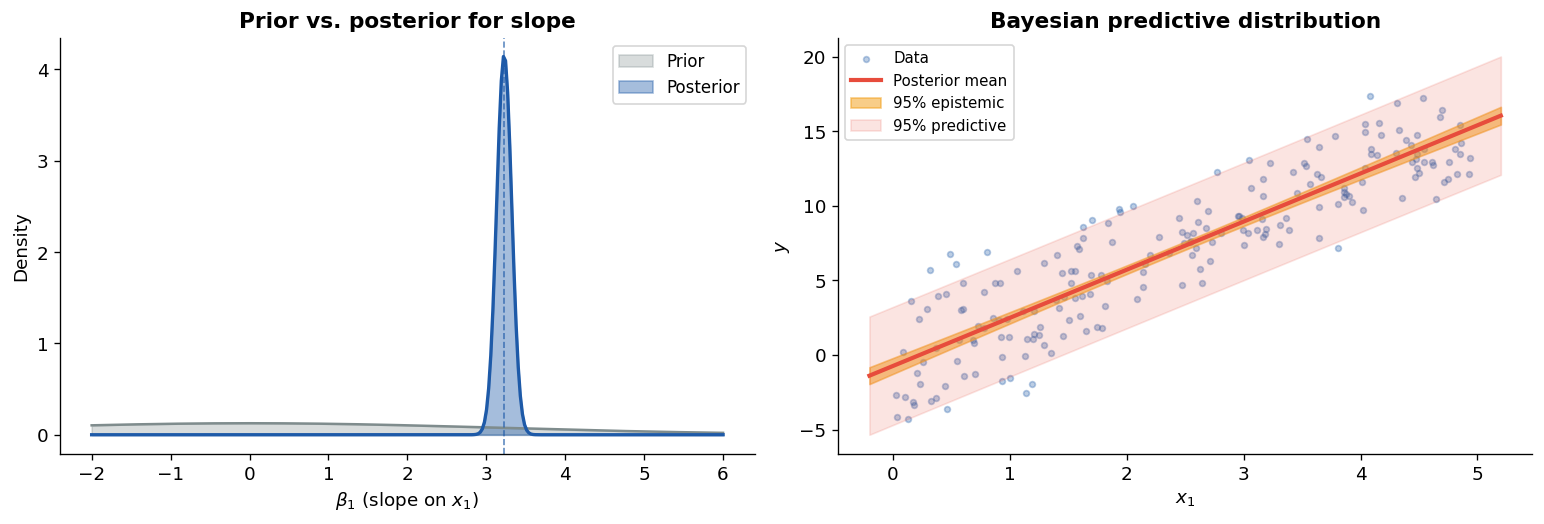

In [11]:
# Visualize: prior -> posterior for the slope parameter
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Prior vs. posterior for slope (beta_1)
beta1_grid = np.linspace(-2, 6, 300)
prior_pdf = stats.norm.pdf(beta1_grid, loc=m_0[1], scale=np.sqrt(S_0[1,1]))
post_pdf = stats.norm.pdf(beta1_grid, loc=m_N[1], scale=np.sqrt(S_N[1,1]))

axes[0].fill_between(beta1_grid, prior_pdf, alpha=0.3, color=GRAY, label='Prior')
axes[0].plot(beta1_grid, prior_pdf, color=GRAY, lw=1.5)
axes[0].fill_between(beta1_grid, post_pdf, alpha=0.4, color=BLUE, label='Posterior')
axes[0].plot(beta1_grid, post_pdf, color=BLUE, lw=2)
axes[0].axvline(m_N[1], color=BLUE, ls='--', lw=1, alpha=0.7)
axes[0].set_xlabel(r'$\beta_1$ (slope on $x_1$)')
axes[0].set_ylabel('Density')
axes[0].set_title('Prior vs. posterior for slope', fontweight='bold')
axes[0].legend(fontsize=10)

# (b) Posterior predictive with uncertainty bands
x_grid = np.linspace(-0.2, 5.2, 200)
X_grid = np.column_stack([np.ones_like(x_grid), x_grid])

y_pred_mean = X_grid @ m_N
# Predictive variance = epistemic + aleatoric
y_pred_var = np.array([x_g @ S_N @ x_g + sigma2 for x_g in X_grid])
y_epistemic_var = np.array([x_g @ S_N @ x_g for x_g in X_grid])
y_pred_std = np.sqrt(y_pred_var)
y_epi_std = np.sqrt(y_epistemic_var)

axes[1].scatter(x1, y, c=BLUE, s=12, alpha=0.3, label='Data')
axes[1].plot(x_grid, y_pred_mean, color=RED, lw=2.5, label='Posterior mean')
axes[1].fill_between(x_grid, y_pred_mean - 1.96*y_epi_std,
                     y_pred_mean + 1.96*y_epi_std,
                     color=GOLD, alpha=0.5, label='95% epistemic')
axes[1].fill_between(x_grid, y_pred_mean - 1.96*y_pred_std,
                     y_pred_mean + 1.96*y_pred_std,
                     color=RED, alpha=0.15, label='95% predictive')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$y$')
axes[1].set_title('Bayesian predictive distribution', fontweight='bold')
axes[1].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

**Reading the right panel:**

- The **gold band** (epistemic uncertainty) represents uncertainty about $\beta$. It is narrow in the center of the data and slightly wider at the edges. With 200 data points the coefficients are well determined, so this band is thin.
- The **red band** (full predictive uncertainty) adds the irreducible observation noise $\sigma^2$. This is the dominant source of uncertainty here.
- **Aleatoric uncertainty** (noise) does not shrink with more data. **Epistemic uncertainty** (parameter uncertainty) does.

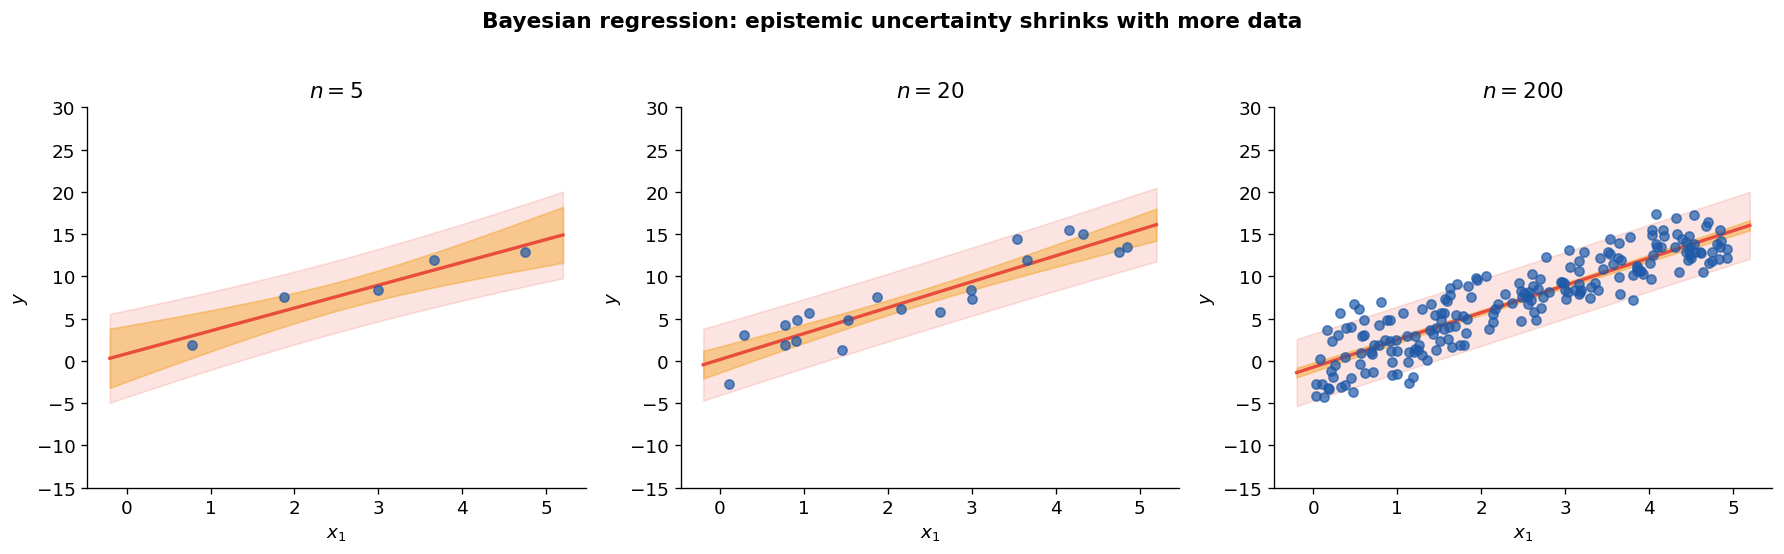

In [12]:
# Demonstrate the effect of prior strength and sample size
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sample_sizes = [5, 20, 200]
for idx, n_sub in enumerate(sample_sizes):
    # Take a subset
    x_sub = x1[:n_sub]
    y_sub = y[:n_sub]
    X_sub = np.column_stack([np.ones(n_sub), x_sub])
    
    # Posterior with the same prior
    S_N_sub_inv = S_0_inv + (1.0 / sigma2) * X_sub.T @ X_sub
    S_N_sub = np.linalg.inv(S_N_sub_inv)
    m_N_sub = S_N_sub @ (S_0_inv @ m_0 + (1.0 / sigma2) * X_sub.T @ y_sub)
    
    # Predictive
    y_mean_sub = X_grid @ m_N_sub
    y_var_sub = np.array([xg @ S_N_sub @ xg + sigma2 for xg in X_grid])
    y_std_sub = np.sqrt(y_var_sub)
    
    axes[idx].scatter(x_sub, y_sub, c=BLUE, s=30, alpha=0.7, zorder=5)
    axes[idx].plot(x_grid, y_mean_sub, color=RED, lw=2)
    axes[idx].fill_between(x_grid, y_mean_sub - 1.96*y_std_sub,
                           y_mean_sub + 1.96*y_std_sub,
                           color=RED, alpha=0.15)
    # Also show epistemic only
    y_epi_sub = np.sqrt(np.array([xg @ S_N_sub @ xg for xg in X_grid]))
    axes[idx].fill_between(x_grid, y_mean_sub - 1.96*y_epi_sub,
                           y_mean_sub + 1.96*y_epi_sub,
                           color=GOLD, alpha=0.4)
    axes[idx].set_xlabel('$x_1$')
    axes[idx].set_ylabel('$y$')
    axes[idx].set_title(f'$n = {n_sub}$', fontweight='bold')
    axes[idx].set_ylim(-15, 30)

fig.suptitle('Bayesian regression: epistemic uncertainty shrinks with more data',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The three panels above are the clearest visual proof of the Bayesian advantage: with only 5 data points, the gold band (epistemic uncertainty) is wide, reflecting genuine ignorance about the slope and intercept. At $n = 200$, the gold band nearly vanishes and the remaining uncertainty is almost entirely aleatoric (irreducible noise).

### Bayesian computation: a brief note

The conjugate Gaussian case above gives an exact closed-form posterior. For more realistic models (nonlinear likelihoods, non-Gaussian priors, hierarchical structure), we approximate:

- **MCMC (e.g., HMC via Stan, PyMC, NumPyro):** Draws samples from the exact posterior. Gold standard but can be slow.
- **Variational Inference (VI):** Approximates the posterior with a simpler distribution. Faster, but potentially biased.
- **Laplace approximation:** Gaussian centered at the MAP. Cheap and sometimes sufficient.

---
## Block 4: PCR, PLS, and Ridge

### The multicollinearity problem

When predictors are highly correlated, $(X^\top X)$ is nearly singular and OLS estimates become unstable (large variance, flipping signs). Three classical responses:

| Method | Strategy | Key property |
|:---|:---|:---|
| **Ridge** | Shrink coefficients toward zero via $\ell_2$ penalty | Closed form: $(X^\top X + \lambda I)^{-1} X^\top y$ |
| **PCR** | Regress $y$ on top-$k$ principal components of $X$ | PCA ignores $y$ (unsupervised compression) |
| **PLS** | Find directions maximizing covariance between $X$ and $y$ | Components are supervised |

In [13]:
# --- Build a dataset with correlated features for PCR/PLS/Ridge demo ---
np.random.seed(42)
n_demo = 300
p_demo = 15

# Create correlated predictors: 3 latent factors with 5 correlated copies each
z1 = np.random.randn(n_demo)
z2 = np.random.randn(n_demo)
z3 = np.random.randn(n_demo)

X_demo = np.column_stack([
    # Group 1: correlated with z1 (the truly predictive factor)
    z1 + 0.3*np.random.randn(n_demo),
    z1 + 0.3*np.random.randn(n_demo),
    z1 + 0.3*np.random.randn(n_demo),
    z1 + 0.3*np.random.randn(n_demo),
    z1 + 0.3*np.random.randn(n_demo),
    # Group 2: correlated with z2 (weakly predictive)
    z2 + 0.3*np.random.randn(n_demo),
    z2 + 0.3*np.random.randn(n_demo),
    z2 + 0.3*np.random.randn(n_demo),
    z2 + 0.3*np.random.randn(n_demo),
    z2 + 0.3*np.random.randn(n_demo),
    # Group 3: high-variance noise (z3), not predictive
    3*z3 + 0.3*np.random.randn(n_demo),
    3*z3 + 0.3*np.random.randn(n_demo),
    3*z3 + 0.3*np.random.randn(n_demo),
    3*z3 + 0.3*np.random.randn(n_demo),
    3*z3 + 0.3*np.random.randn(n_demo),
])

# True signal depends on z1 (strongly) and z2 (weakly). z3 is noise.
y_demo = 5*z1 + 1.5*z2 + np.random.randn(n_demo) * 1.5

# Standardize
scaler = StandardScaler()
X_demo_sc = scaler.fit_transform(X_demo)

print(f"Design matrix: {X_demo_sc.shape[0]} x {X_demo_sc.shape[1]}")
print(f"Condition number of X'X: {np.linalg.cond(X_demo_sc.T @ X_demo_sc):.0f}")
print("\nThe signal lives in z1 (strong) and z2 (weak).")
print("z3 has 3x the variance of z1/z2 but contributes NOTHING to y.")
print("This is designed to make PCR struggle: the top PCs will capture z3 (high variance, no signal).")

Design matrix: 300 x 15
Condition number of X'X: 657

The signal lives in z1 (strong) and z2 (weak).
z3 has 3x the variance of z1/z2 but contributes NOTHING to y.
This is designed to make PCR struggle: the top PCs will capture z3 (high variance, no signal).


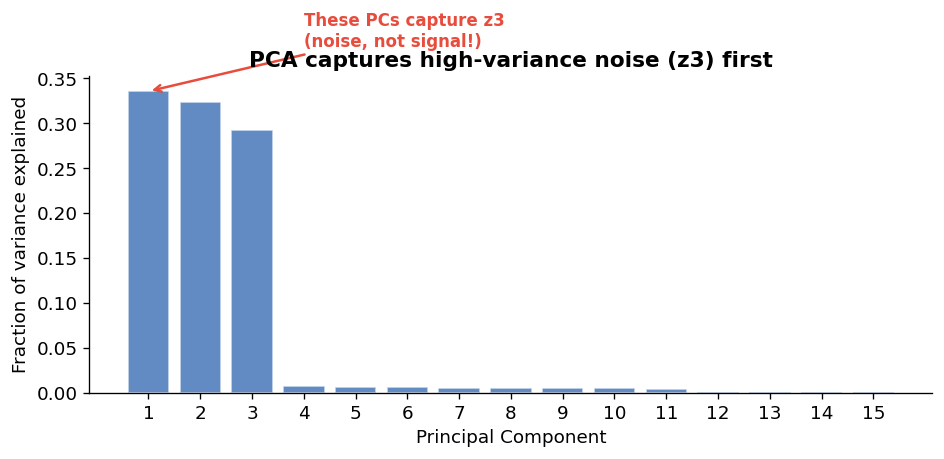

In [14]:
# PCA variance explained: show that the top components capture z3, not the signal
pca_full = PCA().fit(X_demo_sc)

fig, ax = plt.subplots(figsize=(8, 4))
explained = pca_full.explained_variance_ratio_
ax.bar(range(1, p_demo+1), explained, color=BLUE, alpha=0.7, edgecolor='white')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Fraction of variance explained')
ax.set_title('PCA captures high-variance noise (z3) first', fontweight='bold')
ax.set_xticks(range(1, p_demo+1))

# Annotate
ax.annotate('These PCs capture z3\n(noise, not signal!)',
           xy=(1, explained[0]), xytext=(4, explained[0]+0.05),
           arrowprops=dict(arrowstyle='->', color=RED, lw=1.5),
           fontsize=10, color=RED, fontweight='bold')

plt.tight_layout()
plt.show()

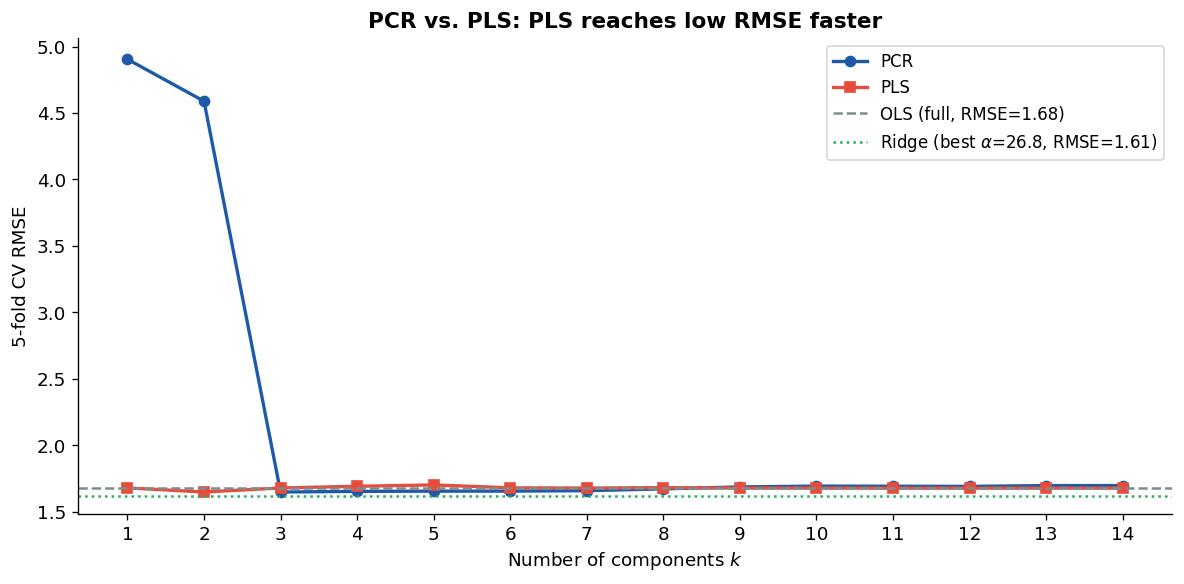


Best PCR: k=3, RMSE=1.647
Best PLS: k=2, RMSE=1.647
Ridge:    alpha=26.83, RMSE=1.614
OLS:      RMSE=1.677


In [15]:
# --- Compare PCR, PLS, Ridge: CV RMSE vs. number of components / alpha ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
max_comp = 14

pcr_rmses = []
pls_rmses = []

for k in range(1, max_comp + 1):
    # PCR
    pcr_pipe = Pipeline([('pca', PCA(n_components=k)), ('lr', LinearRegression())])
    scores_pcr = cross_val_score(pcr_pipe, X_demo_sc, y_demo, cv=kf,
                                 scoring='neg_root_mean_squared_error')
    pcr_rmses.append(-scores_pcr.mean())
    
    # PLS
    pls_pipe = PLSRegression(n_components=k, scale=False)
    scores_pls = cross_val_score(pls_pipe, X_demo_sc, y_demo, cv=kf,
                                 scoring='neg_root_mean_squared_error')
    pls_rmses.append(-scores_pls.mean())

# Ridge for comparison
ridge_cv = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=kf)
ridge_cv.fit(X_demo_sc, y_demo)
ridge_rmse = np.sqrt(mean_squared_error(y_demo, ridge_cv.predict(X_demo_sc)))

# OLS baseline
ols_scores = cross_val_score(LinearRegression(), X_demo_sc, y_demo, cv=kf,
                             scoring='neg_root_mean_squared_error')
ols_rmse = -ols_scores.mean()

fig, ax = plt.subplots(figsize=(10, 5))
comps = range(1, max_comp + 1)
ax.plot(comps, pcr_rmses, 'o-', color=BLUE, lw=2, label='PCR')
ax.plot(comps, pls_rmses, 's-', color=RED, lw=2, label='PLS')
ax.axhline(ols_rmse, color=GRAY, ls='--', lw=1.5, label=f'OLS (full, RMSE={ols_rmse:.2f})')
ax.axhline(ridge_rmse, color=GREEN, ls=':', lw=1.5,
           label=f'Ridge (best $\\alpha$={ridge_cv.alpha_:.1f}, RMSE={ridge_rmse:.2f})')

ax.set_xlabel('Number of components $k$')
ax.set_ylabel('5-fold CV RMSE')
ax.set_title('PCR vs. PLS: PLS reaches low RMSE faster', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(list(comps))

plt.tight_layout()
plt.show()

print(f"\nBest PCR: k={np.argmin(pcr_rmses)+1}, RMSE={min(pcr_rmses):.3f}")
print(f"Best PLS: k={np.argmin(pls_rmses)+1}, RMSE={min(pls_rmses):.3f}")
print(f"Ridge:    alpha={ridge_cv.alpha_:.2f}, RMSE={ridge_rmse:.3f}")
print(f"OLS:      RMSE={ols_rmse:.3f}")

**Key observation:** PLS reaches its minimum RMSE with far fewer components than PCR. This is because PLS components are *supervised*: they maximize covariance with $y$, so they find the signal (z1, z2) directly. PCR components are *unsupervised*: the first few PCs capture the high-variance noise group (z3) and miss the signal.

Ridge avoids the component-selection problem entirely by shrinking all coefficients smoothly. In practice, Ridge is often the simplest and most robust choice among these three.

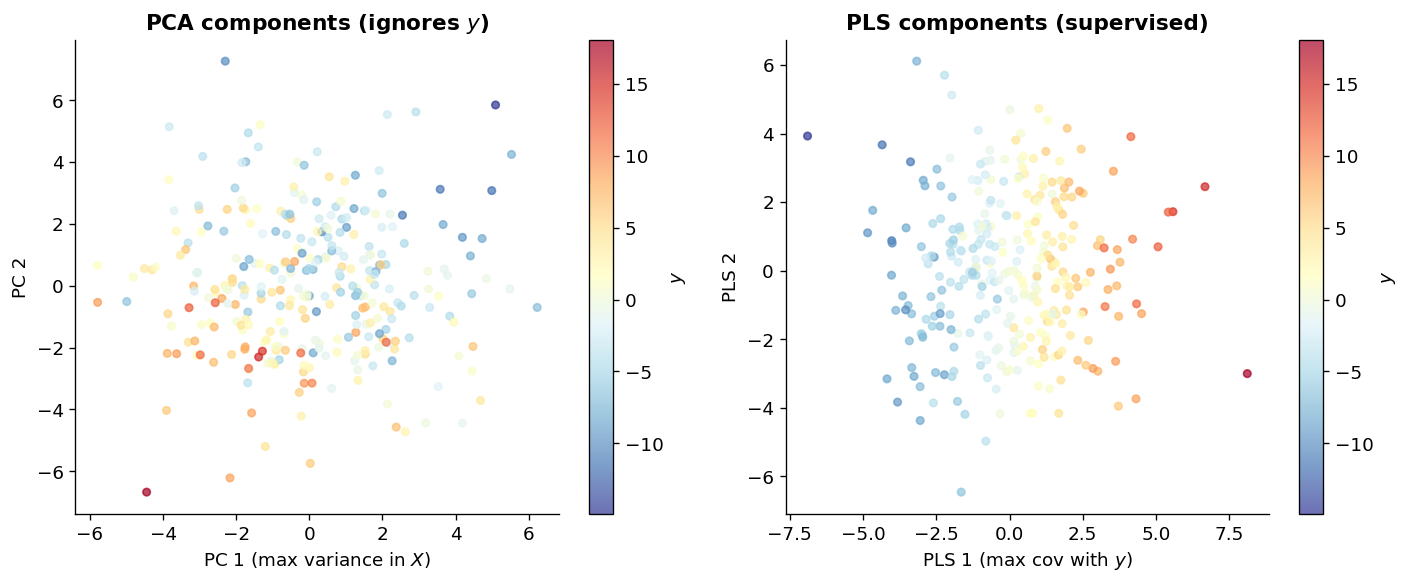

In the right panel (PLS), the color gradient aligns with the first component.
In the left panel (PCA), the first component captures z3 (high variance, no signal),
so there is no clear color gradient along PC1.


In [16]:
# Visualize what PCR vs PLS "sees" -- project data onto first 2 components
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PCR components
pca_2 = PCA(n_components=2).fit(X_demo_sc)
Z_pca = pca_2.transform(X_demo_sc)
sc0 = axes[0].scatter(Z_pca[:, 0], Z_pca[:, 1], c=y_demo, cmap='RdYlBu_r', s=20, alpha=0.7)
axes[0].set_xlabel('PC 1 (max variance in $X$)')
axes[0].set_ylabel('PC 2')
axes[0].set_title('PCA components (ignores $y$)', fontweight='bold')
plt.colorbar(sc0, ax=axes[0], label='$y$')

# PLS components
pls_2 = PLSRegression(n_components=2, scale=False).fit(X_demo_sc, y_demo)
Z_pls = pls_2.transform(X_demo_sc)
sc1 = axes[1].scatter(Z_pls[:, 0], Z_pls[:, 1], c=y_demo, cmap='RdYlBu_r', s=20, alpha=0.7)
axes[1].set_xlabel('PLS 1 (max cov with $y$)')
axes[1].set_ylabel('PLS 2')
axes[1].set_title('PLS components (supervised)', fontweight='bold')
plt.colorbar(sc1, ax=axes[1], label='$y$')

plt.tight_layout()
plt.show()

print("In the right panel (PLS), the color gradient aligns with the first component.")
print("In the left panel (PCA), the first component captures z3 (high variance, no signal),")
print("so there is no clear color gradient along PC1.")

In [17]:
# --- Robustness test: add 50 noise features ---
# To make the comparison fair, we CV-tune the number of components
# for both PCR and PLS rather than fixing them arbitrarily.
np.random.seed(0)
X_noisy = np.hstack([X_demo_sc, np.random.randn(n_demo, 50)])
print(f"Extended design matrix: {X_noisy.shape[0]} x {X_noisy.shape[1]}")

# Find best k for PCR and PLS by CV on the noisy data
best_pcr_k, best_pcr_rmse = 1, np.inf
best_pls_k, best_pls_rmse = 1, np.inf
for k in range(1, 16):
    pcr_k = Pipeline([('pca', PCA(n_components=k)), ('lr', LinearRegression())])
    rmse_k = -cross_val_score(pcr_k, X_noisy, y_demo, cv=kf,
                              scoring='neg_root_mean_squared_error').mean()
    if rmse_k < best_pcr_rmse:
        best_pcr_rmse, best_pcr_k = rmse_k, k
    
    pls_k = PLSRegression(n_components=k, scale=False)
    rmse_k = -cross_val_score(pls_k, X_noisy, y_demo, cv=kf,
                              scoring='neg_root_mean_squared_error').mean()
    if rmse_k < best_pls_rmse:
        best_pls_rmse, best_pls_k = rmse_k, k

methods = {
    'OLS': LinearRegression(),
    'Ridge': RidgeCV(alphas=np.logspace(-2, 4, 50), cv=kf),
    f'PCR (k={best_pcr_k})': Pipeline([('pca', PCA(n_components=best_pcr_k)),
                                        ('lr', LinearRegression())]),
    f'PLS (k={best_pls_k})': PLSRegression(n_components=best_pls_k, scale=False),
}

print("\n5-fold CV RMSE with 50 noise features added (k tuned by CV):")
print("-" * 55)
noisy_results = {}
for name, model in methods.items():
    scores = cross_val_score(model, X_noisy, y_demo, cv=kf,
                             scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    noisy_results[name] = rmse
    print(f"  {name:15s}  RMSE = {rmse:.3f} +/- {scores.std():.3f}")

# Data-driven conclusion
best_method = min(noisy_results, key=noisy_results.get)
worst_method = max(noisy_results, key=noisy_results.get)
print(f"\nBest: {best_method} (RMSE = {noisy_results[best_method]:.3f})")
print(f"Worst: {worst_method} (RMSE = {noisy_results[worst_method]:.3f})")
print("\nWith CV-tuned component counts, PLS needs fewer components to reach")
print("a competitive RMSE. Both PLS and PCR outperform OLS, which overfits")
print("to the 50 noise columns. Ridge also handles the noise well via shrinkage.")

Extended design matrix: 300 x 65



5-fold CV RMSE with 50 noise features added (k tuned by CV):
-------------------------------------------------------
  OLS              RMSE = 1.936 +/- 0.137


  Ridge            RMSE = 1.825 +/- 0.167
  PCR (k=11)       RMSE = 1.796 +/- 0.106
  PLS (k=2)        RMSE = 1.782 +/- 0.107

Best: PLS (k=2) (RMSE = 1.782)
Worst: OLS (RMSE = 1.936)

With CV-tuned component counts, PLS needs fewer components to reach
a competitive RMSE. Both PLS and PCR outperform OLS, which overfits
to the 50 noise columns. Ridge also handles the noise well via shrinkage.


---
## Block 5: Feature Selection & Wrap-up

### Feature selection for regression

When you have many candidate predictors, selecting a subset can improve interpretability and sometimes predictive performance. Three broad strategies:

| Strategy | How it works | Examples |
|:---|:---|:---|
| **Filter** | Rank features by a score (correlation, mutual information) independent of the model | Pearson $r$, F-test, mutual information |
| **Wrapper** | Search subsets and evaluate each with the model itself | Forward selection, backward elimination, recursive feature elimination (RFE) |
| **Embedded** | Feature selection happens during model fitting | Lasso ($\ell_1$ penalty drives coefficients to zero), Elastic Net |

Lasso is the most widely used embedded method. By construction, some $\hat{\beta}_j$ are set exactly to zero, yielding a sparse model.

<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_541/3950254261.py:30: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Lasso coefficient path: feature selection via $\ell_1$ penalty', fontweight='bold')


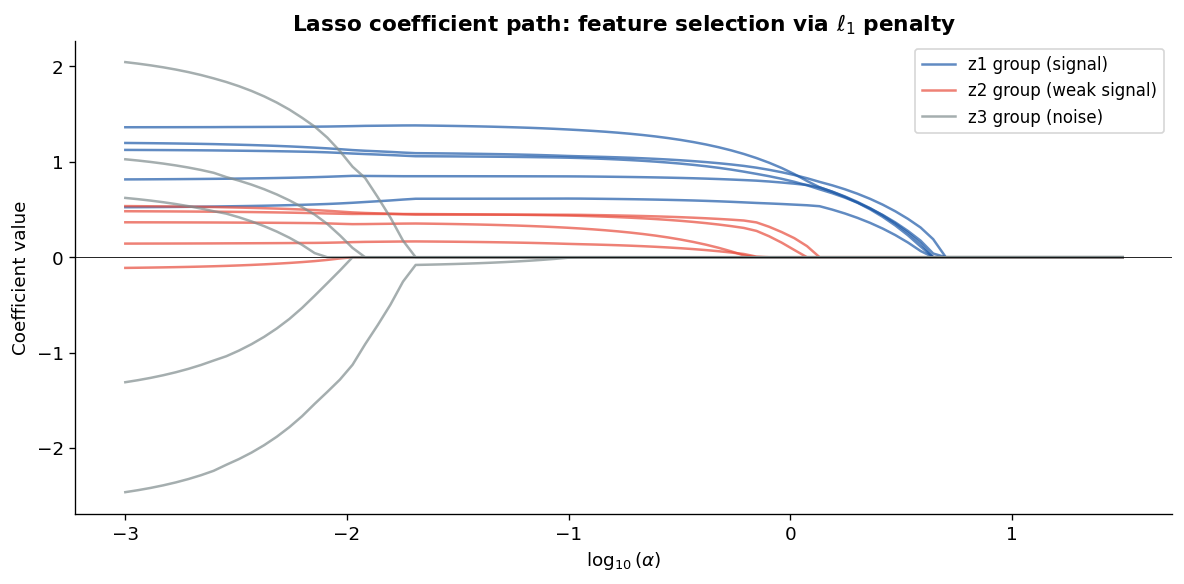

As alpha increases, Lasso drives noise features (gray) to zero first,
then the weak-signal features (red), keeping the strong-signal features (blue) longest.
This is embedded feature selection: the penalty does the work.


In [18]:
# Demo: Lasso coefficient path -- which features survive?
alphas_lasso = np.logspace(-3, 1.5, 80)
coefs_path = []
for a in alphas_lasso:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_demo_sc, y_demo)
    coefs_path.append(lasso.coef_.copy())
coefs_path = np.array(coefs_path)

fig, ax = plt.subplots(figsize=(10, 5))
# Color groups
colors_feat = [BLUE]*5 + [RED]*5 + [GRAY]*5
labels_done = set()
for j in range(p_demo):
    if j < 5:
        lbl = 'z1 group (signal)' if 'z1 group (signal)' not in labels_done else None
        labels_done.add('z1 group (signal)')
    elif j < 10:
        lbl = 'z2 group (weak signal)' if 'z2 group (weak signal)' not in labels_done else None
        labels_done.add('z2 group (weak signal)')
    else:
        lbl = 'z3 group (noise)' if 'z3 group (noise)' not in labels_done else None
        labels_done.add('z3 group (noise)')
    ax.plot(np.log10(alphas_lasso), coefs_path[:, j],
            color=colors_feat[j], lw=1.5, alpha=0.7, label=lbl)

ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('$\\log_{10}(\\alpha)$')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso coefficient path: feature selection via $\ell_1$ penalty', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("As alpha increases, Lasso drives noise features (gray) to zero first,")
print("then the weak-signal features (red), keeping the strong-signal features (blue) longest.")
print("This is embedded feature selection: the penalty does the work.")

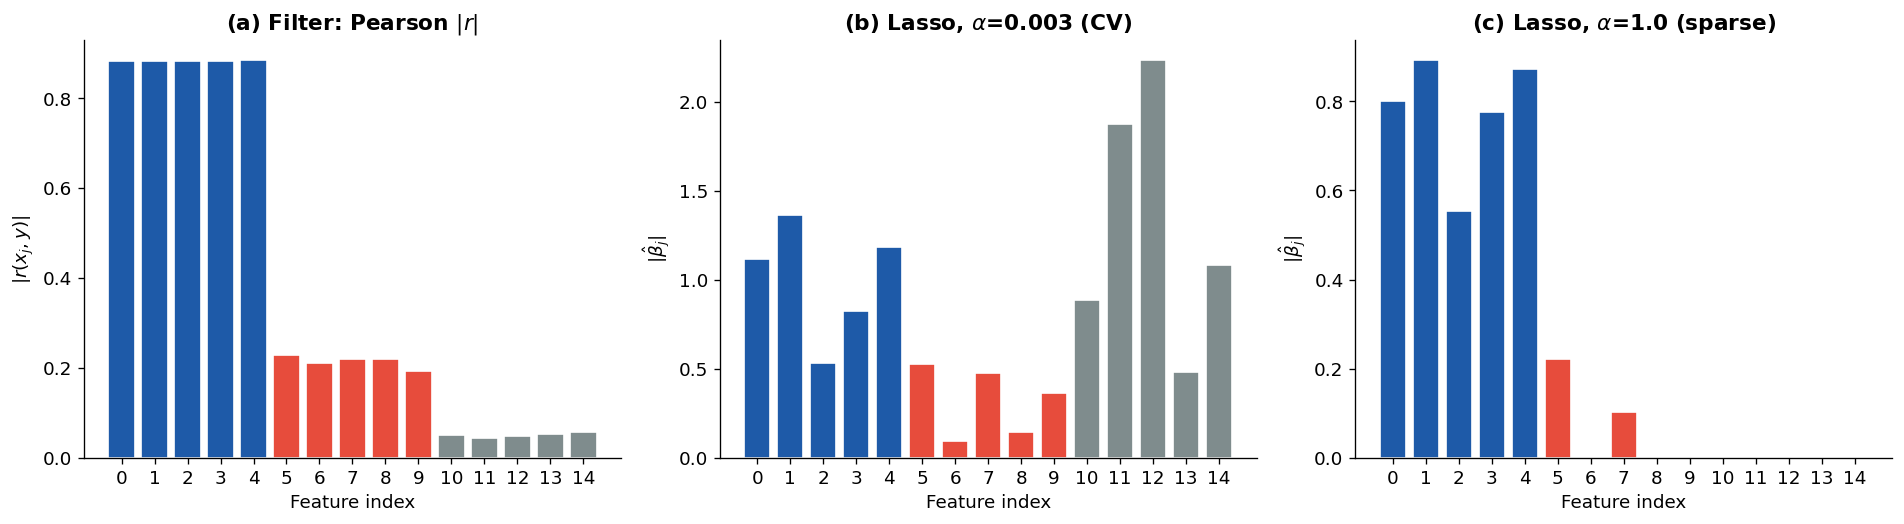

CV-selected alpha = 0.0025: 15 / 15 features active
   -> alpha is small, so the penalty barely acts. All features survive,
      including the noise group (gray bars are large). This is nearly OLS.

Stronger alpha = 1.0: 7 / 15 features active
   -> The penalty zeros out noise (gray) and weak-signal (red) features.
      Only the signal group (blue) survives.

Lesson: the CV-selected alpha optimizes prediction, not sparsity.
If interpretability matters, you may prefer a sparser model at some cost in RMSE.


In [19]:
# Quick comparison: filter method (correlation) vs. Lasso selection
correlations = np.array([np.corrcoef(X_demo_sc[:, j], y_demo)[0, 1]
                         for j in range(p_demo)])

# Lasso with CV-tuned alpha
lasso_cv = LassoCV(alphas=np.logspace(-3, 1.5, 80), cv=kf, max_iter=10000)
lasso_cv.fit(X_demo_sc, y_demo)

# Also fit Lasso at a stronger alpha to show actual sparsity
alpha_sparse = 1.0  # strong enough to zero out noise features
lasso_sparse = Lasso(alpha=alpha_sparse, max_iter=10000)
lasso_sparse.fit(X_demo_sc, y_demo)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

bar_colors = [BLUE]*5 + [RED]*5 + [GRAY]*5

# (a) Filter: correlation
axes[0].bar(range(p_demo), np.abs(correlations), color=bar_colors, edgecolor='white')
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('$|r(x_j, y)|$')
axes[0].set_title('(a) Filter: Pearson $|r|$', fontweight='bold')
axes[0].set_xticks(range(p_demo))

# (b) Lasso at CV-selected alpha (weak penalty, nearly OLS)
axes[1].bar(range(p_demo), np.abs(lasso_cv.coef_), color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('$|\\hat{\\beta}_j|$')
axes[1].set_title(f'(b) Lasso, $\\alpha$={lasso_cv.alpha_:.3f} (CV)', fontweight='bold')
axes[1].set_xticks(range(p_demo))

# (c) Lasso at stronger alpha (actual sparsity)
axes[2].bar(range(p_demo), np.abs(lasso_sparse.coef_), color=bar_colors, edgecolor='white')
axes[2].set_xlabel('Feature index')
axes[2].set_ylabel('$|\\hat{\\beta}_j|$')
axes[2].set_title(f'(c) Lasso, $\\alpha$={alpha_sparse:.1f} (sparse)', fontweight='bold')
axes[2].set_xticks(range(p_demo))

plt.tight_layout()
plt.show()

n_nonzero_cv = np.sum(np.abs(lasso_cv.coef_) > 1e-6)
n_nonzero_sp = np.sum(np.abs(lasso_sparse.coef_) > 1e-6)
print(f"CV-selected alpha = {lasso_cv.alpha_:.4f}: {n_nonzero_cv} / {p_demo} features active")
print(f"   -> alpha is small, so the penalty barely acts. All features survive,")
print(f"      including the noise group (gray bars are large). This is nearly OLS.")
print(f"\nStronger alpha = {alpha_sparse}: {n_nonzero_sp} / {p_demo} features active")
print(f"   -> The penalty zeros out noise (gray) and weak-signal (red) features.")
print(f"      Only the signal group (blue) survives.")
print(f"\nLesson: the CV-selected alpha optimizes prediction, not sparsity.")
print(f"If interpretability matters, you may prefer a sparser model at some cost in RMSE.")

### Summary and method comparison

| Method | Strengths | Weaknesses | When to use |
|:---|:---|:---|:---|
| **OLS** | Closed form, unbiased, full inference | Fails with collinearity, $p > n$ | $n \gg p$, low collinearity |
| **Ridge** | Handles collinearity, closed form | Biased, all coefficients nonzero | Correlated features |
| **Lasso** | Sparse solutions, feature selection | Struggles with correlated groups | Many features, need sparsity |
| **PCR** | Dimensionality reduction | Ignores $y$: top PCs may miss signal | Signal in top PCs |
| **PLS** | Supervised dim. reduction, handles $p \gg n$ | Overfits if $k$ too large | Signal in low-variance directions |
| **Bayesian** | Full posterior, uncertainty quantification | Computationally heavier | Need uncertainty, small $n$ |

**Decision guide:**
- High $n/p$, clean data, need interpretability: start with OLS.
- Collinear features: Ridge or PLS.
- Many features, need sparsity: Lasso or Elastic Net.
- Need uncertainty quantification: Bayesian.
- Nonlinear patterns survive in diagnostics: consider flexible models (trees, neural nets).
- Always: fit, diagnose, then decide.

### Takeaways

1. **Taxonomy.** Supervised learning decomposes into regression ($y \in \mathbb{R}$) and classification ($y$ discrete). Same optimization framework, different loss.

2. **Start simple.** OLS is the baseline. It projects $y$ onto the column space of $X$ and provides interpretable coefficients.

3. **Diagnostics first.** Fit, then check residual plots, Q-Q, leverage, Cook's distance. Never trust $R^2$ alone.

4. **Bayesian regression** gives a full posterior distribution. The posterior mean with a Gaussian prior is equivalent to Ridge. The key added value is uncertainty quantification: the predictive distribution separates aleatoric from epistemic uncertainty.

5. **PLS vs. PCR.** PLS finds directions that maximize covariance with $y$; PCA maximizes variance in $X$ and can chase noise.

6. **Feature selection.** Lasso provides built-in selection via the $\ell_1$ penalty. Filter methods (correlation) are model-free alternatives. Choose based on interpretability needs.

7. **Method choice** depends on $n/p$, collinearity, interpretability, and whether you need uncertainty. When in doubt, start with OLS, diagnose, and escalate as needed.